# Alternative Payments  and its recent possible impact on the acquire market

In recent years, transaccions with electronic wallets have been strongly increasing, deeply related with the BCRP's efforts and work for the an interoperable payment system, in this notebook we analyze how this events could be related or even affect to the acquirer market.

The main question to answer is:

**There is sharp increase in the use of alternative payments, is this replacing or transforming person-to-merchant payment acceptance??**

In [1]:
import sys
from functools import reduce
from pathlib import Path

# Add project root to Python path
PROJECT_ROOT = Path.cwd().parents[1]

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import catppuccin
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
from matplotlib.ticker import StrMethodFormatter

from bcrp_analytics.utils import build_bcrp_dataset, get_bcrp_clean_series

pd.options.display.float_format = "{:,.2f}".format
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)
plt.style.use("mocha")

# Fetch Data

In [2]:
prepaid_cards_fees = {
    # Total amount in millions
    "PN42725EM": "pago_tarjetas_prepago_total",
    "PN42165EM": "pago_tarjetas_debito",
    "PN42168EM": "pago_tarjetas_credito",
    "PN42166EM": "pago_tarjetas_debito_online",
    "PN42167EM": "pago_tarjetas_debito_offline",
    "PN42169EM": "pago_tarjetas_credito_online",
    "PN42170EM": "pago_tarjetas_credito_offline",
    # number of transactions in thousands
    "PN42193EM": "ntrx_tarjetas_total",
    "PN42194EM": "ntrx_tarjetas_debito",
    "PN42197EM": "ntrx_tarjetas_credito",
    "PN42195EM": "ntrx_tarjetas_debito_online",
    "PN42196EM": "ntrx_tarjetas_debito_offline",
    "PN42198EM": "ntrx_tarjetas_credito_online",
    "PN42199EM": "ntrx_tarjetas_credito_offline",
}

electronic_money = {
    "PN42209EM": "ntrx_dinero_electronico",
    "PN42180EM": "mto_dinero_electronico",
}

In [4]:
card_payment_data = build_bcrp_dataset(prepaid_cards_fees)
electronic_data = build_bcrp_dataset(electronic_money)

/Users/luisfernandocorcueraleon/Desktop/code/BCRP-ANALYTICS/bcrp_analytics/utils.py:241: UserWarning: Warning: Some series contain missing ovservations due to selecting series with different data ranges
  warnings.warn(


In [5]:
electronic_data.tail()

,period,ntrx_dinero_electronico,mto_dinero_electronico
55,2021-12-01,0.71,125.43
56,2021-11-01,0.77,119.65
57,2021-10-01,0.71,115.44
58,2021-09-01,0.68,111.42
59,2021-08-01,0.70,99.43


In [6]:
electronic_data[["ntrx_dinero_electronico", "period"]].tail(10)

,ntrx_dinero_electronico,period
50,0.59,2022-05-01
51,0.58,2022-04-01
52,0.65,2022-03-01
53,0.57,2022-02-01
54,0.65,2022-01-01
55,0.71,2021-12-01
56,0.77,2021-11-01
57,0.71,2021-10-01
58,0.68,2021-09-01
59,0.70,2021-08-01


# 1. Who drives growth in the electronic money market? 

To understand this new phenomena we must define who are the actors:

1. Electronic money issuers: Companies that hold user's money and back them up with real money mass, some of the most important are: Gmoney, Tarjetas Peruanas Prepago, Servitebca y Peruana Soluciones. There also exist new possible players such as Prex, Bipay, Lemon and Onekey.

2. Wallet and apps: These are the apps that clients use, these could belong to issuers or use the infraestructure from aother entities.

3. Transfer infraesetructure: CCCE, LBTR system, and other rails allow to move money between entities, they opening to EEDES is crutial in this proces.

4. Merchant acceptance: IF the acquieres products accpet payments with these wallets

# 2. Analyzing how payments via electronic wallets have evolved

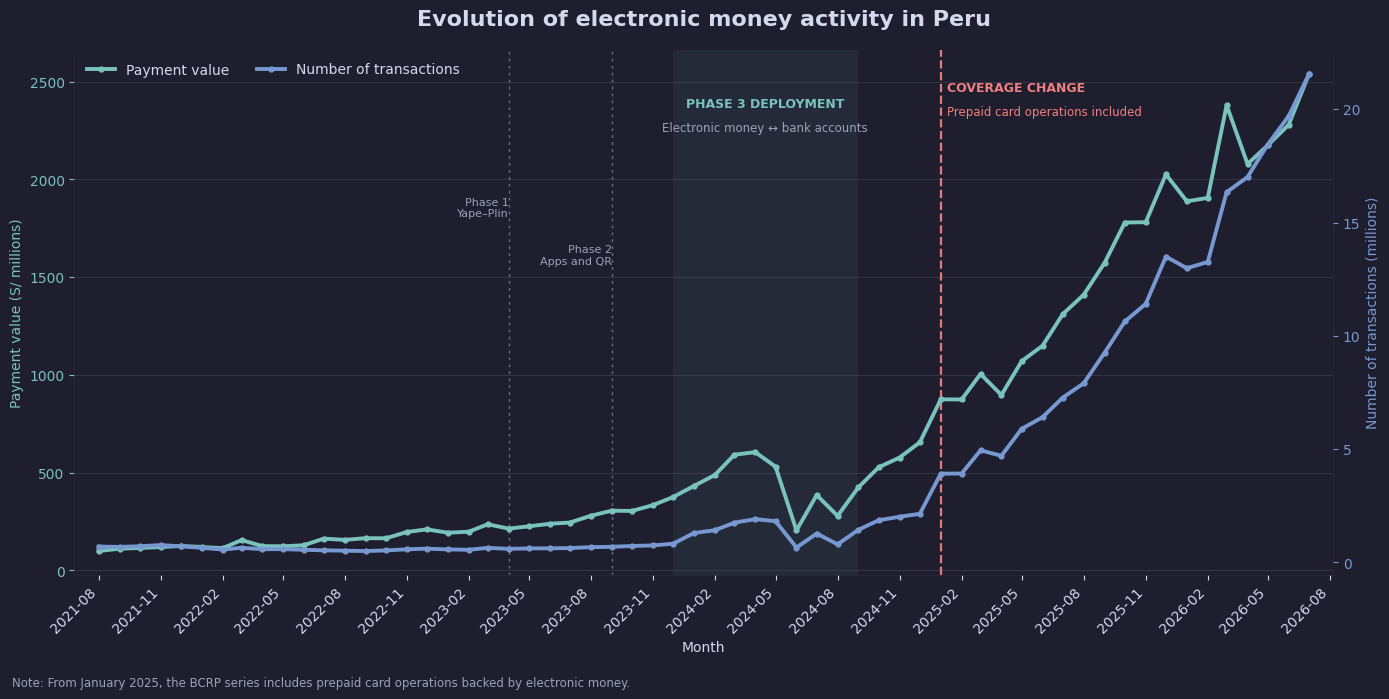

In [7]:
import matplotlib.dates as mdates

electronic_data = electronic_data.sort_values("period").copy()

VALUE_COLOR = "#79C2BD"
TRX_COLOR = "#7798D1"
TEXT_COLOR = "#D5D9EE"
MUTED_COLOR = "#9CA3B5"
GRID_COLOR = "#5C6172"
BREAK_COLOR = "#F08080"

fig, ax1 = plt.subplots(figsize=(14, 7))
ax2 = ax1.twinx()

phase3_start = pd.Timestamp("2023-12-01")
phase3_end = pd.Timestamp("2024-09-01")

ax1.axvspan(
    phase3_start,
    phase3_end,
    color=VALUE_COLOR,
    alpha=0.08,
    linewidth=0,
    zorder=0,
)

ax1.text(
    pd.Timestamp("2024-04-15"),
    0.91,
    "PHASE 3 DEPLOYMENT",
    transform=ax1.get_xaxis_transform(),
    ha="center",
    va="top",
    fontsize=9,
    fontweight="bold",
    color=VALUE_COLOR,
)

ax1.text(
    pd.Timestamp("2024-04-15"),
    0.865,
    "Electronic money ↔ bank accounts",
    transform=ax1.get_xaxis_transform(),
    ha="center",
    va="top",
    fontsize=8.5,
    color=MUTED_COLOR,
)

# ------------------------------------------------------------------
# Interoperability milestones
# ------------------------------------------------------------------
milestones = [
    ("2023-04-01", "Phase 1\nYape–Plin", 0.72),
    ("2023-09-01", "Phase 2\nApps and QR", 0.63),
]

for date, label, label_height in milestones:
    date = pd.Timestamp(date)

    ax1.axvline(
        date,
        color=MUTED_COLOR,
        linestyle=(0, (2, 3)),
        linewidth=1,
        alpha=0.60,
        zorder=1,
    )

    ax1.text(
        date,
        label_height,
        label,
        transform=ax1.get_xaxis_transform(),
        ha="right",
        va="top",
        fontsize=8,
        color=MUTED_COLOR,
    )

# ------------------------------------------------------------------
# Methodological break
# ------------------------------------------------------------------
coverage_break = pd.Timestamp("2025-01-01")

ax1.axvline(
    coverage_break,
    color=BREAK_COLOR,
    linestyle="--",
    linewidth=1.6,
    alpha=0.95,
    zorder=2,
)

ax1.text(
    coverage_break + pd.DateOffset(days=10),
    0.94,
    "COVERAGE CHANGE",
    transform=ax1.get_xaxis_transform(),
    ha="left",
    va="top",
    fontsize=9,
    fontweight="bold",
    color=BREAK_COLOR,
)

ax1.text(
    coverage_break + pd.DateOffset(days=10),
    0.895,
    "Prepaid card operations included",
    transform=ax1.get_xaxis_transform(),
    ha="left",
    va="top",
    fontsize=8.5,
    color=BREAK_COLOR,
)

# ------------------------------------------------------------------
# Main series
# ------------------------------------------------------------------
line_value = ax1.plot(
    electronic_data["period"],
    electronic_data["mto_dinero_electronico"],
    color=VALUE_COLOR,
    linewidth=2.8,
    marker="o",
    markersize=3.5,
    label="Payment value",
    zorder=4,
)

line_transactions = ax2.plot(
    electronic_data["period"],
    electronic_data["ntrx_dinero_electronico"],
    color=TRX_COLOR,
    linewidth=2.8,
    marker="o",
    markersize=3.5,
    label="Number of transactions",
    zorder=4,
)

# ------------------------------------------------------------------
# Labels and formatting
# ------------------------------------------------------------------
ax1.set_title(
    "Evolution of electronic money activity in Peru",
    fontsize=16,
    fontweight="bold",
    color=TEXT_COLOR,
    pad=18,
)

ax1.set_xlabel("Month", color=TEXT_COLOR)

ax1.set_ylabel(
    "Payment value (S/ millions)",
    color=VALUE_COLOR,
)

ax2.set_ylabel(
    "Number of transactions (millions)",
    color=TRX_COLOR,
)

ax1.tick_params(axis="x", colors=TEXT_COLOR)
ax1.tick_params(axis="y", colors=VALUE_COLOR)
ax2.tick_params(axis="y", colors=TRX_COLOR)

ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=3))

ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

plt.setp(
    ax1.get_xticklabels(),
    rotation=45,
    ha="right",
)

ax1.grid(
    axis="y",
    color=GRID_COLOR,
    linewidth=0.7,
    alpha=0.35,
)

ax1.grid(axis="x", visible=False)
ax1.set_axisbelow(True)
ax1.margins(x=0.02)

for ax in (ax1, ax2):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_alpha(0.25)
    ax.spines["left"].set_alpha(0.25)
    ax.spines["bottom"].set_alpha(0.25)

# Combined legend
lines = line_value + line_transactions
labels = [line.get_label() for line in lines]

ax1.legend(
    lines,
    labels,
    frameon=False,
    loc="upper left",
    ncol=2,
    labelcolor=TEXT_COLOR,
)

fig.text(
    0.012,
    0.012,
    "Note: From January 2025, the BCRP series includes prepaid card "
    "operations backed by electronic money.",
    fontsize=8.5,
    color=MUTED_COLOR,
    ha="left",
)

plt.tight_layout(rect=(0, 0.035, 1, 1))
plt.show()

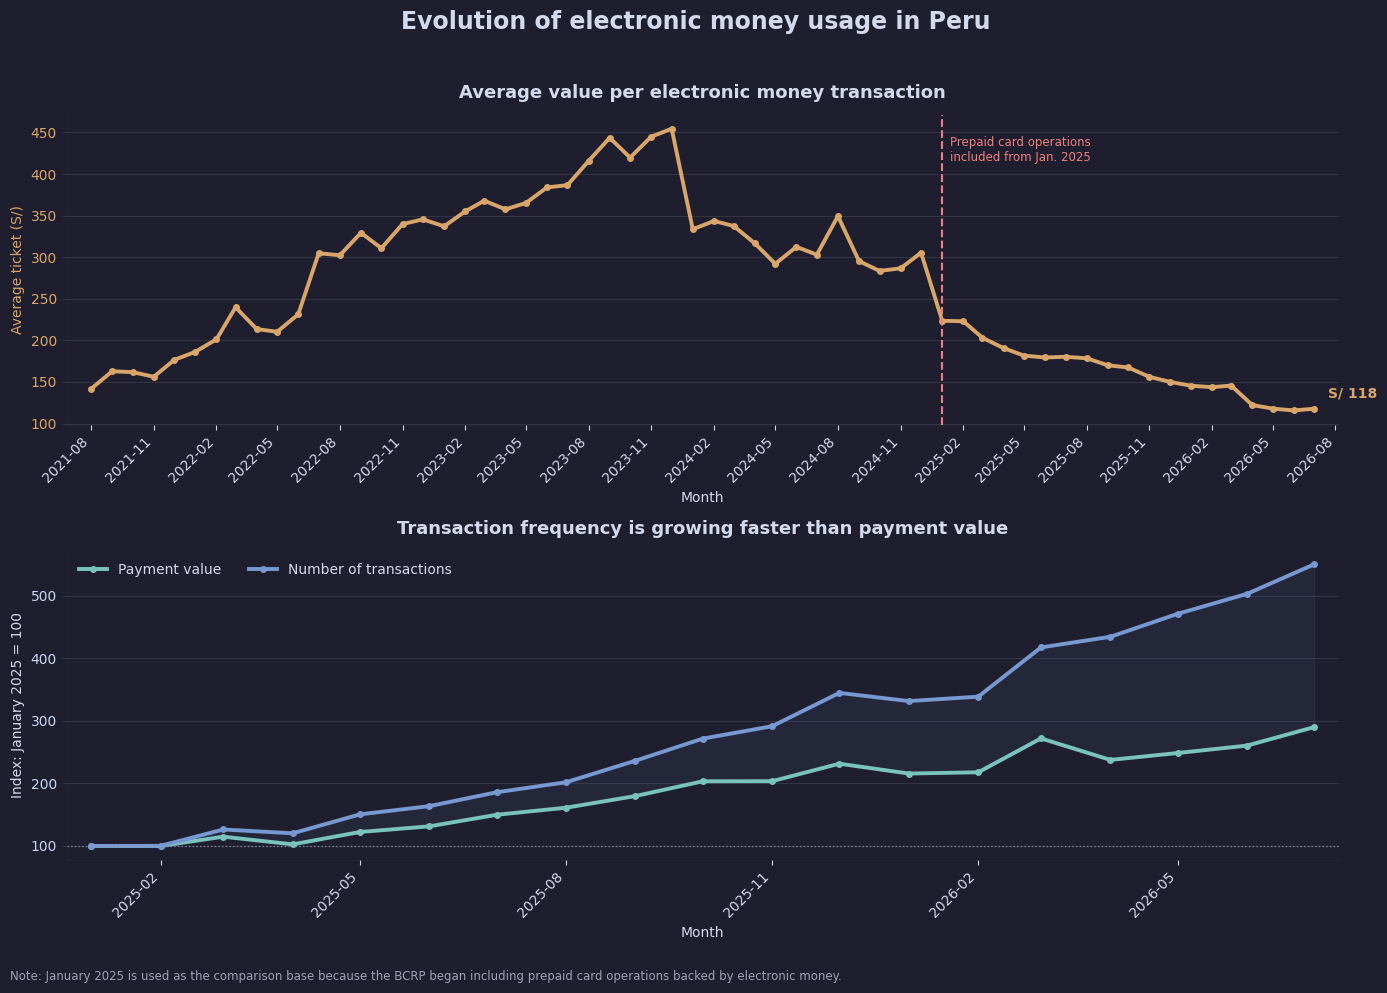

In [8]:
import matplotlib.dates as mdates

electronic_ticket = electronic_data.sort_values("period").copy()


electronic_ticket["average_ticket"] = np.where(
    electronic_ticket["ntrx_dinero_electronico"] > 0,
    electronic_ticket["mto_dinero_electronico"]
    / electronic_ticket["ntrx_dinero_electronico"],
    np.nan,
)


comparison_start = pd.Timestamp("2025-01-01")

indexed_data = electronic_ticket.loc[
    electronic_ticket["period"] >= comparison_start
].copy()

indexed_data["payment_value_index"] = (
    indexed_data["mto_dinero_electronico"]
    / indexed_data["mto_dinero_electronico"].iloc[0]
    * 100
)

indexed_data["transactions_index"] = (
    indexed_data["ntrx_dinero_electronico"]
    / indexed_data["ntrx_dinero_electronico"].iloc[0]
    * 100
)


TICKET_COLOR = "#D8A66A"
VALUE_COLOR = "#79C2BD"
TRX_COLOR = "#7798D1"
TEXT_COLOR = "#D5D9EE"
MUTED_COLOR = "#9CA3B5"
GRID_COLOR = "#5C6172"
BREAK_COLOR = "#F08080"

fig, axes = plt.subplots(
    2,
    1,
    figsize=(14, 10),
    sharex=False,
    gridspec_kw={"height_ratios": [1, 1]},
)

fig.suptitle(
    "Evolution of electronic money usage in Peru",
    fontsize=17,
    fontweight="bold",
    color=TEXT_COLOR,
    y=0.98,
)

# ==================================================================
# Plot 1: Average ticket
# ==================================================================
ax = axes[0]

ax.plot(
    electronic_ticket["period"],
    electronic_ticket["average_ticket"],
    color=TICKET_COLOR,
    linewidth=2.8,
    marker="o",
    markersize=4,
)

ax.axvline(
    comparison_start,
    color=BREAK_COLOR,
    linestyle="--",
    linewidth=1.5,
)

ax.text(
    comparison_start + pd.DateOffset(days=12),
    0.93,
    "Prepaid card operations\nincluded from Jan. 2025",
    transform=ax.get_xaxis_transform(),
    ha="left",
    va="top",
    fontsize=8.5,
    color=BREAK_COLOR,
)

ax.set_title(
    "Average value per electronic money transaction",
    fontsize=13,
    fontweight="bold",
    color=TEXT_COLOR,
    pad=12,
)

ax.set_ylabel(
    "Average ticket (S/)",
    color=TICKET_COLOR,
)

ax.tick_params(
    axis="y",
    labelcolor=TICKET_COLOR,
)

# Latest value annotation
latest = electronic_ticket.dropna(subset=["average_ticket"]).iloc[-1]

ax.annotate(
    f"S/ {latest['average_ticket']:.0f}",
    xy=(latest["period"], latest["average_ticket"]),
    xytext=(10, 8),
    textcoords="offset points",
    fontsize=10,
    fontweight="bold",
    color=TICKET_COLOR,
)

# ==================================================================
# Plot 2: Indexed amount versus transactions
# ==================================================================
ax = axes[1]

ax.plot(
    indexed_data["period"],
    indexed_data["payment_value_index"],
    color=VALUE_COLOR,
    linewidth=2.8,
    marker="o",
    markersize=4,
    label="Payment value",
)

ax.plot(
    indexed_data["period"],
    indexed_data["transactions_index"],
    color=TRX_COLOR,
    linewidth=2.8,
    marker="o",
    markersize=4,
    label="Number of transactions",
)

ax.axhline(
    100,
    color=MUTED_COLOR,
    linestyle=":",
    linewidth=1,
    alpha=0.7,
)

ax.fill_between(
    indexed_data["period"],
    indexed_data["payment_value_index"],
    indexed_data["transactions_index"],
    where=(indexed_data["transactions_index"] >= indexed_data["payment_value_index"]),
    color=TRX_COLOR,
    alpha=0.08,
)

ax.set_title(
    "Transaction frequency is growing faster than payment value",
    fontsize=13,
    fontweight="bold",
    color=TEXT_COLOR,
    pad=12,
)

ax.set_ylabel(
    "Index: January 2025 = 100",
    color=TEXT_COLOR,
)

ax.legend(
    frameon=False,
    loc="upper left",
    ncol=2,
    labelcolor=TEXT_COLOR,
)

# ==================================================================
# General formatting
# ==================================================================
for ax in axes:
    ax.set_xlabel("Month", color=TEXT_COLOR)

    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))

    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

    ax.tick_params(
        axis="x",
        colors=TEXT_COLOR,
    )

    plt.setp(
        ax.get_xticklabels(),
        rotation=45,
        ha="right",
    )

    ax.grid(
        axis="y",
        color=GRID_COLOR,
        linewidth=0.7,
        alpha=0.35,
    )

    ax.grid(axis="x", visible=False)
    ax.set_axisbelow(True)
    ax.margins(x=0.02)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_alpha(0.25)
    ax.spines["bottom"].set_alpha(0.25)

fig.text(
    0.01,
    0.01,
    "Note: January 2025 is used as the comparison base because the BCRP "
    "began including prepaid card operations backed by electronic money.",
    fontsize=8.5,
    color=MUTED_COLOR,
    ha="left",
)

plt.tight_layout(rect=(0, 0.035, 1, 0.96))
plt.show()

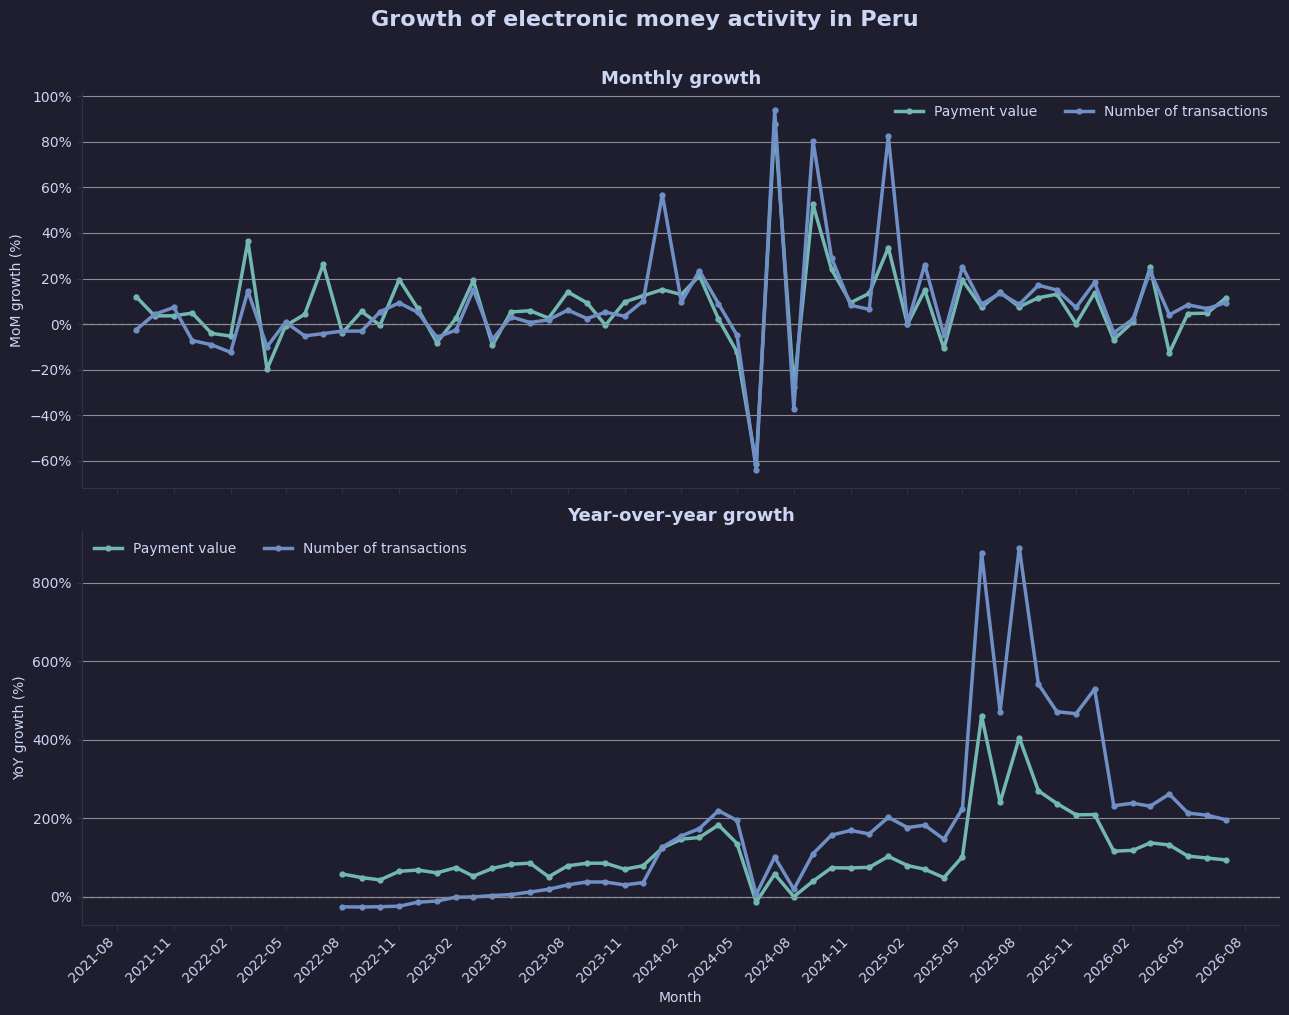

In [9]:
from matplotlib.ticker import PercentFormatter

electronic_data = electronic_data.sort_values("period").copy()

# Monthly growth
electronic_data["var_mto_m"] = electronic_data["mto_dinero_electronico"].pct_change()

electronic_data["var_ntrx_m"] = electronic_data["ntrx_dinero_electronico"].pct_change()

# Year-over-year growth
electronic_data["var_mto_yoy"] = electronic_data["mto_dinero_electronico"].pct_change(
    12
)

electronic_data["var_ntrx_yoy"] = electronic_data["ntrx_dinero_electronico"].pct_change(
    12
)

# Pastel corporate colors
value_color = "#72B7B2"
transactions_color = "#6F8FC5"

fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(13, 10),
    sharex=True,
)

# ---------------------------------------------------------------
# Monthly growth
# ---------------------------------------------------------------

axes[0].plot(
    electronic_data["period"],
    electronic_data["var_mto_m"],
    color=value_color,
    linewidth=2.5,
    marker="o",
    markersize=3.5,
    label="Payment value",
)

axes[0].plot(
    electronic_data["period"],
    electronic_data["var_ntrx_m"],
    color=transactions_color,
    linewidth=2.5,
    marker="o",
    markersize=3.5,
    label="Number of transactions",
)

axes[0].axhline(
    0,
    color="#8C8C8C",
    linewidth=1,
    linestyle="--",
    alpha=0.7,
)

axes[0].set_title(
    "Monthly growth",
    fontsize=13,
    fontweight="bold",
)

axes[0].set_ylabel("MoM growth (%)")
axes[0].yaxis.set_major_formatter(PercentFormatter(1))
axes[0].legend(frameon=False, ncol=2)

# ---------------------------------------------------------------
# Year-over-year growth
# ---------------------------------------------------------------

axes[1].plot(
    electronic_data["period"],
    electronic_data["var_mto_yoy"],
    color=value_color,
    linewidth=2.5,
    marker="o",
    markersize=3.5,
    label="Payment value",
)

axes[1].plot(
    electronic_data["period"],
    electronic_data["var_ntrx_yoy"],
    color=transactions_color,
    linewidth=2.5,
    marker="o",
    markersize=3.5,
    label="Number of transactions",
)

axes[1].axhline(
    0,
    color="#8C8C8C",
    linewidth=1,
    linestyle="--",
    alpha=0.7,
)

axes[1].set_title(
    "Year-over-year growth",
    fontsize=13,
    fontweight="bold",
)

axes[1].set_ylabel("YoY growth (%)")
axes[1].set_xlabel("Month")
axes[1].yaxis.set_major_formatter(PercentFormatter(1))
axes[1].legend(frameon=False, ncol=2)

# ---------------------------------------------------------------
# General formatting
# ---------------------------------------------------------------

for ax in axes:
    ax.grid(
        axis="y",
        color="#D9D9D9",
        linewidth=0.8,
        alpha=0.6,
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=3))

axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

plt.setp(
    axes[1].get_xticklabels(),
    rotation=45,
    ha="right",
)

fig.suptitle(
    "Growth of electronic money activity in Peru",
    fontsize=16,
    fontweight="bold",
    y=1.01,
)

plt.tight_layout()
plt.show()

# 2. Card payments

In [10]:
card_payment_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   period                         60 non-null     datetime64[ns]
 1   pago_tarjetas_prepago_total    31 non-null     float64       
 2   pago_tarjetas_debito           60 non-null     float64       
 3   pago_tarjetas_credito          60 non-null     float64       
 4   pago_tarjetas_debito_online    31 non-null     float64       
 5   pago_tarjetas_debito_offline   31 non-null     float64       
 6   pago_tarjetas_credito_online   31 non-null     float64       
 7   pago_tarjetas_credito_offline  31 non-null     float64       
 8   ntrx_tarjetas_total            60 non-null     float64       
 9   ntrx_tarjetas_debito           60 non-null     float64       
 10  ntrx_tarjetas_credito          60 non-null     float64       
 11  ntrx_tarjetas_debito_

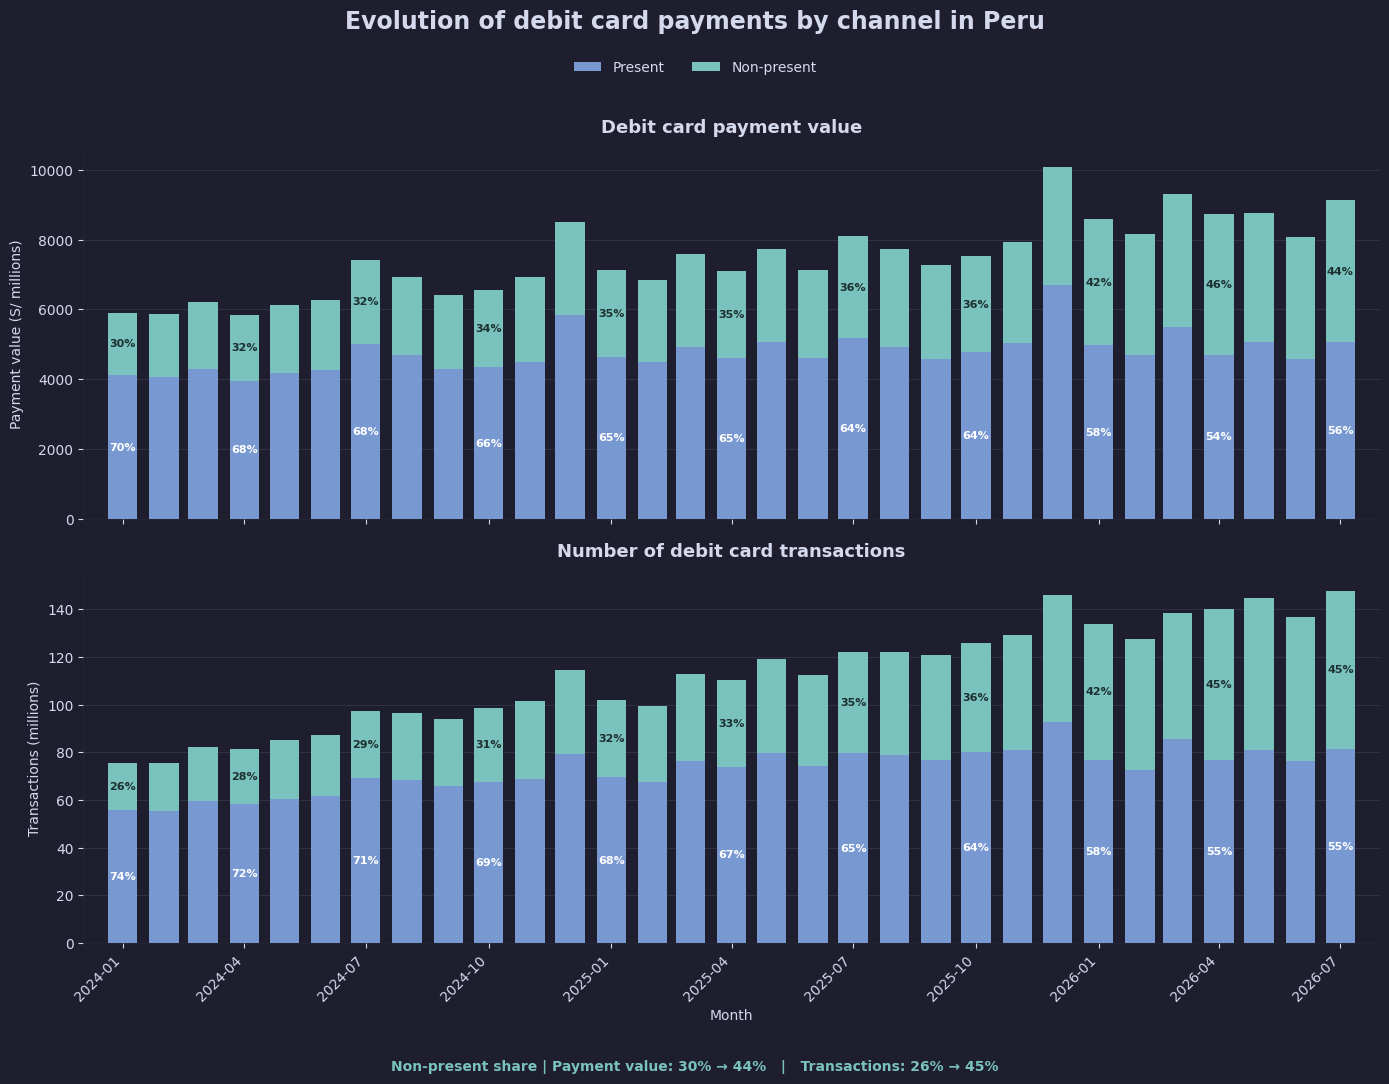

In [11]:
debit_data = (
    card_payment_data.sort_values("period")
    .dropna(
        subset=[
            "pago_tarjetas_debito_online",
            "pago_tarjetas_debito_offline",
            "ntrx_tarjetas_debito_online",
            "ntrx_tarjetas_debito_offline",
        ]
    )
    .copy()
)

# Totals reconstructed from channel components
debit_data["debit_payment_total_channels"] = (
    debit_data["pago_tarjetas_debito_online"]
    + debit_data["pago_tarjetas_debito_offline"]
)

debit_data["debit_transactions_total_channels"] = (
    debit_data["ntrx_tarjetas_debito_online"]
    + debit_data["ntrx_tarjetas_debito_offline"]
)

# Shares
debit_data["payment_present_share"] = (
    debit_data["pago_tarjetas_debito_offline"]
    / debit_data["debit_payment_total_channels"]
)

debit_data["payment_nonpresent_share"] = (
    debit_data["pago_tarjetas_debito_online"]
    / debit_data["debit_payment_total_channels"]
)

debit_data["transactions_present_share"] = (
    debit_data["ntrx_tarjetas_debito_offline"]
    / debit_data["debit_transactions_total_channels"]
)

debit_data["transactions_nonpresent_share"] = (
    debit_data["ntrx_tarjetas_debito_online"]
    / debit_data["debit_transactions_total_channels"]
)

# ------------------------------------------------------------------
# Colors
# ------------------------------------------------------------------
PRESENT_COLOR = "#7798D1"
NONPRESENT_COLOR = "#79C2BD"

TEXT_COLOR = "#D5D9EE"
MUTED_COLOR = "#9CA3B5"
GRID_COLOR = "#5C6172"

fig, axes = plt.subplots(
    2,
    1,
    figsize=(14, 11),
    sharex=True,
)

fig.suptitle(
    "Evolution of debit card payments by channel in Peru",
    fontsize=17,
    fontweight="bold",
    color=TEXT_COLOR,
    y=0.98,
)

bar_width = 22

# ==================================================================
# Plot 1: Payment value
# ==================================================================
ax = axes[0]

ax.bar(
    debit_data["period"],
    debit_data["pago_tarjetas_debito_offline"],
    width=bar_width,
    color=PRESENT_COLOR,
    label="Present",
)

ax.bar(
    debit_data["period"],
    debit_data["pago_tarjetas_debito_online"],
    width=bar_width,
    bottom=debit_data["pago_tarjetas_debito_offline"],
    color=NONPRESENT_COLOR,
    label="Non-present",
)

ax.set_title(
    "Debit card payment value",
    fontsize=13,
    fontweight="bold",
    color=TEXT_COLOR,
    pad=12,
)

ax.set_ylabel(
    "Payment value (S/ millions)",
    color=TEXT_COLOR,
)

# ==================================================================
# Plot 2: Number of transactions
# ==================================================================
ax = axes[1]

ax.bar(
    debit_data["period"],
    debit_data["ntrx_tarjetas_debito_offline"],
    width=bar_width,
    color=PRESENT_COLOR,
    label="Present",
)

ax.bar(
    debit_data["period"],
    debit_data["ntrx_tarjetas_debito_online"],
    width=bar_width,
    bottom=debit_data["ntrx_tarjetas_debito_offline"],
    color=NONPRESENT_COLOR,
    label="Non-present",
)

ax.set_title(
    "Number of debit card transactions",
    fontsize=13,
    fontweight="bold",
    color=TEXT_COLOR,
    pad=12,
)

ax.set_ylabel(
    "Transactions (millions)",
    color=TEXT_COLOR,
)

ax.set_xlabel(
    "Month",
    color=TEXT_COLOR,
)

# ==================================================================
# Percentage labels
# Label every three months plus the latest observation
# ==================================================================
label_positions = sorted(set(range(0, len(debit_data), 3)) | {len(debit_data) - 1})

# Plot 1 labels
for i in label_positions:
    row = debit_data.iloc[i]

    present_value = row["pago_tarjetas_debito_offline"]
    nonpresent_value = row["pago_tarjetas_debito_online"]

    axes[0].text(
        row["period"],
        present_value / 2,
        f"{row['payment_present_share']:.0%}",
        ha="center",
        va="center",
        fontsize=8,
        fontweight="bold",
        color="#FFFFFF",
    )

    axes[0].text(
        row["period"],
        present_value + nonpresent_value / 2,
        f"{row['payment_nonpresent_share']:.0%}",
        ha="center",
        va="center",
        fontsize=8,
        fontweight="bold",
        color="#1D3030",
    )

# Plot 2 labels
for i in label_positions:
    row = debit_data.iloc[i]

    present_transactions = row["ntrx_tarjetas_debito_offline"]
    nonpresent_transactions = row["ntrx_tarjetas_debito_online"]

    axes[1].text(
        row["period"],
        present_transactions / 2,
        f"{row['transactions_present_share']:.0%}",
        ha="center",
        va="center",
        fontsize=8,
        fontweight="bold",
        color="#FFFFFF",
    )

    axes[1].text(
        row["period"],
        present_transactions + nonpresent_transactions / 2,
        f"{row['transactions_nonpresent_share']:.0%}",
        ha="center",
        va="center",
        fontsize=8,
        fontweight="bold",
        color="#1D3030",
    )

# ==================================================================
# Formatting
# ==================================================================
for ax in axes:
    ax.tick_params(
        axis="both",
        colors=TEXT_COLOR,
    )

    ax.grid(
        axis="y",
        color=GRID_COLOR,
        linewidth=0.7,
        alpha=0.30,
    )

    ax.grid(axis="x", visible=False)
    ax.set_axisbelow(True)
    ax.margins(x=0.02)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_alpha(0.25)
    ax.spines["bottom"].set_alpha(0.25)

axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=3))

axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

plt.setp(
    axes[1].get_xticklabels(),
    rotation=45,
    ha="right",
)

# Shared legend
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.945),
    ncol=2,
    frameon=False,
    labelcolor=TEXT_COLOR,
)

# ------------------------------------------------------------------
# Dynamic summary
# ------------------------------------------------------------------
first = debit_data.iloc[0]
latest = debit_data.iloc[-1]

summary = (
    f"Non-present share | Payment value: "
    f"{first['payment_nonpresent_share']:.0%} → "
    f"{latest['payment_nonpresent_share']:.0%}   |   "
    f"Transactions: "
    f"{first['transactions_nonpresent_share']:.0%} → "
    f"{latest['transactions_nonpresent_share']:.0%}"
)

fig.text(
    0.5,
    0.015,
    summary,
    ha="center",
    fontsize=10,
    fontweight="bold",
    color=NONPRESENT_COLOR,
)

plt.tight_layout(rect=(0, 0.045, 1, 0.93))
plt.show()

In [12]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd


def plot_card_channel_mix(
    data,
    card_type="credito",
    card_label="Credit",
):
    """
    Plot payment value and transaction volume by present/non-present
    channel for a selected card type.

    Parameters
    ----------
    data : pandas.DataFrame
        Card payment dataframe.
    card_type : str
        'credito' or 'debito'.
    card_label : str
        Display label: 'Credit' or 'Debit'.
    """

    # --------------------------------------------------------------
    # Column names
    # --------------------------------------------------------------
    payment_online = f"pago_tarjetas_{card_type}_online"
    payment_offline = f"pago_tarjetas_{card_type}_offline"

    transactions_online = f"ntrx_tarjetas_{card_type}_online"
    transactions_offline = f"ntrx_tarjetas_{card_type}_offline"

    # --------------------------------------------------------------
    # Prepare data
    # --------------------------------------------------------------
    plot_data = (
        data.sort_values("period")
        .dropna(
            subset=[
                payment_online,
                payment_offline,
                transactions_online,
                transactions_offline,
            ]
        )
        .copy()
    )

    plot_data["payment_total_channels"] = (
        plot_data[payment_online] + plot_data[payment_offline]
    )

    plot_data["transactions_total_channels"] = (
        plot_data[transactions_online] + plot_data[transactions_offline]
    )

    plot_data["payment_present_share"] = (
        plot_data[payment_offline] / plot_data["payment_total_channels"]
    )

    plot_data["payment_nonpresent_share"] = (
        plot_data[payment_online] / plot_data["payment_total_channels"]
    )

    plot_data["transactions_present_share"] = (
        plot_data[transactions_offline] / plot_data["transactions_total_channels"]
    )

    plot_data["transactions_nonpresent_share"] = (
        plot_data[transactions_online] / plot_data["transactions_total_channels"]
    )

    # --------------------------------------------------------------
    # Colors
    # --------------------------------------------------------------
    PRESENT_COLOR = "#7798D1"
    NONPRESENT_COLOR = "#79C2BD"

    TEXT_COLOR = "#D5D9EE"
    GRID_COLOR = "#5C6172"

    fig, axes = plt.subplots(
        2,
        1,
        figsize=(14, 11),
        sharex=True,
    )

    fig.suptitle(
        f"Evolution of {card_label.lower()} card payments by channel in Peru",
        fontsize=17,
        fontweight="bold",
        color=TEXT_COLOR,
        y=0.98,
    )

    bar_width = 22

    # ==============================================================
    # Payment value
    # ==============================================================
    axes[0].bar(
        plot_data["period"],
        plot_data[payment_offline],
        width=bar_width,
        color=PRESENT_COLOR,
        label="Present",
    )

    axes[0].bar(
        plot_data["period"],
        plot_data[payment_online],
        width=bar_width,
        bottom=plot_data[payment_offline],
        color=NONPRESENT_COLOR,
        label="Non-present",
    )

    axes[0].set_title(
        f"{card_label} card payment value",
        fontsize=13,
        fontweight="bold",
        color=TEXT_COLOR,
        pad=12,
    )

    axes[0].set_ylabel(
        "Payment value (S/ millions)",
        color=TEXT_COLOR,
    )

    # ==============================================================
    # Number of transactions
    # ==============================================================
    axes[1].bar(
        plot_data["period"],
        plot_data[transactions_offline],
        width=bar_width,
        color=PRESENT_COLOR,
        label="Present",
    )

    axes[1].bar(
        plot_data["period"],
        plot_data[transactions_online],
        width=bar_width,
        bottom=plot_data[transactions_offline],
        color=NONPRESENT_COLOR,
        label="Non-present",
    )

    axes[1].set_title(
        f"Number of {card_label.lower()} card transactions",
        fontsize=13,
        fontweight="bold",
        color=TEXT_COLOR,
        pad=12,
    )

    axes[1].set_ylabel(
        "Transactions (millions)",
        color=TEXT_COLOR,
    )

    axes[1].set_xlabel(
        "Month",
        color=TEXT_COLOR,
    )

    # ==============================================================
    # Percentage labels
    # ==============================================================
    label_positions = sorted(set(range(0, len(plot_data), 3)) | {len(plot_data) - 1})

    for i in label_positions:
        row = plot_data.iloc[i]

        # Payment-value labels
        present_value = row[payment_offline]
        nonpresent_value = row[payment_online]

        axes[0].text(
            row["period"],
            present_value / 2,
            f"{row['payment_present_share']:.0%}",
            ha="center",
            va="center",
            fontsize=8,
            fontweight="bold",
            color="#FFFFFF",
        )

        axes[0].text(
            row["period"],
            present_value + nonpresent_value / 2,
            f"{row['payment_nonpresent_share']:.0%}",
            ha="center",
            va="center",
            fontsize=8,
            fontweight="bold",
            color="#1D3030",
        )

        # Transaction labels
        present_transactions = row[transactions_offline]
        nonpresent_transactions = row[transactions_online]

        axes[1].text(
            row["period"],
            present_transactions / 2,
            f"{row['transactions_present_share']:.0%}",
            ha="center",
            va="center",
            fontsize=8,
            fontweight="bold",
            color="#FFFFFF",
        )

        axes[1].text(
            row["period"],
            present_transactions + nonpresent_transactions / 2,
            f"{row['transactions_nonpresent_share']:.0%}",
            ha="center",
            va="center",
            fontsize=8,
            fontweight="bold",
            color="#1D3030",
        )

    # ==============================================================
    # Formatting
    # ==============================================================
    for ax in axes:
        ax.tick_params(
            axis="both",
            colors=TEXT_COLOR,
        )

        ax.grid(
            axis="y",
            color=GRID_COLOR,
            linewidth=0.7,
            alpha=0.30,
        )

        ax.grid(axis="x", visible=False)
        ax.set_axisbelow(True)
        ax.margins(x=0.02)

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["left"].set_alpha(0.25)
        ax.spines["bottom"].set_alpha(0.25)

    axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=3))

    axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

    plt.setp(
        axes[1].get_xticklabels(),
        rotation=45,
        ha="right",
    )

    # Shared legend
    handles, labels = axes[0].get_legend_handles_labels()

    fig.legend(
        handles,
        labels,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.945),
        ncol=2,
        frameon=False,
        labelcolor=TEXT_COLOR,
    )

    # Dynamic summary
    first = plot_data.iloc[0]
    latest = plot_data.iloc[-1]

    summary = (
        f"Non-present share | Payment value: "
        f"{first['payment_nonpresent_share']:.0%} → "
        f"{latest['payment_nonpresent_share']:.0%}   |   "
        f"Transactions: "
        f"{first['transactions_nonpresent_share']:.0%} → "
        f"{latest['transactions_nonpresent_share']:.0%}"
    )

    fig.text(
        0.5,
        0.015,
        summary,
        ha="center",
        fontsize=10,
        fontweight="bold",
        color=NONPRESENT_COLOR,
    )

    plt.tight_layout(rect=(0, 0.045, 1, 0.93))
    plt.show()

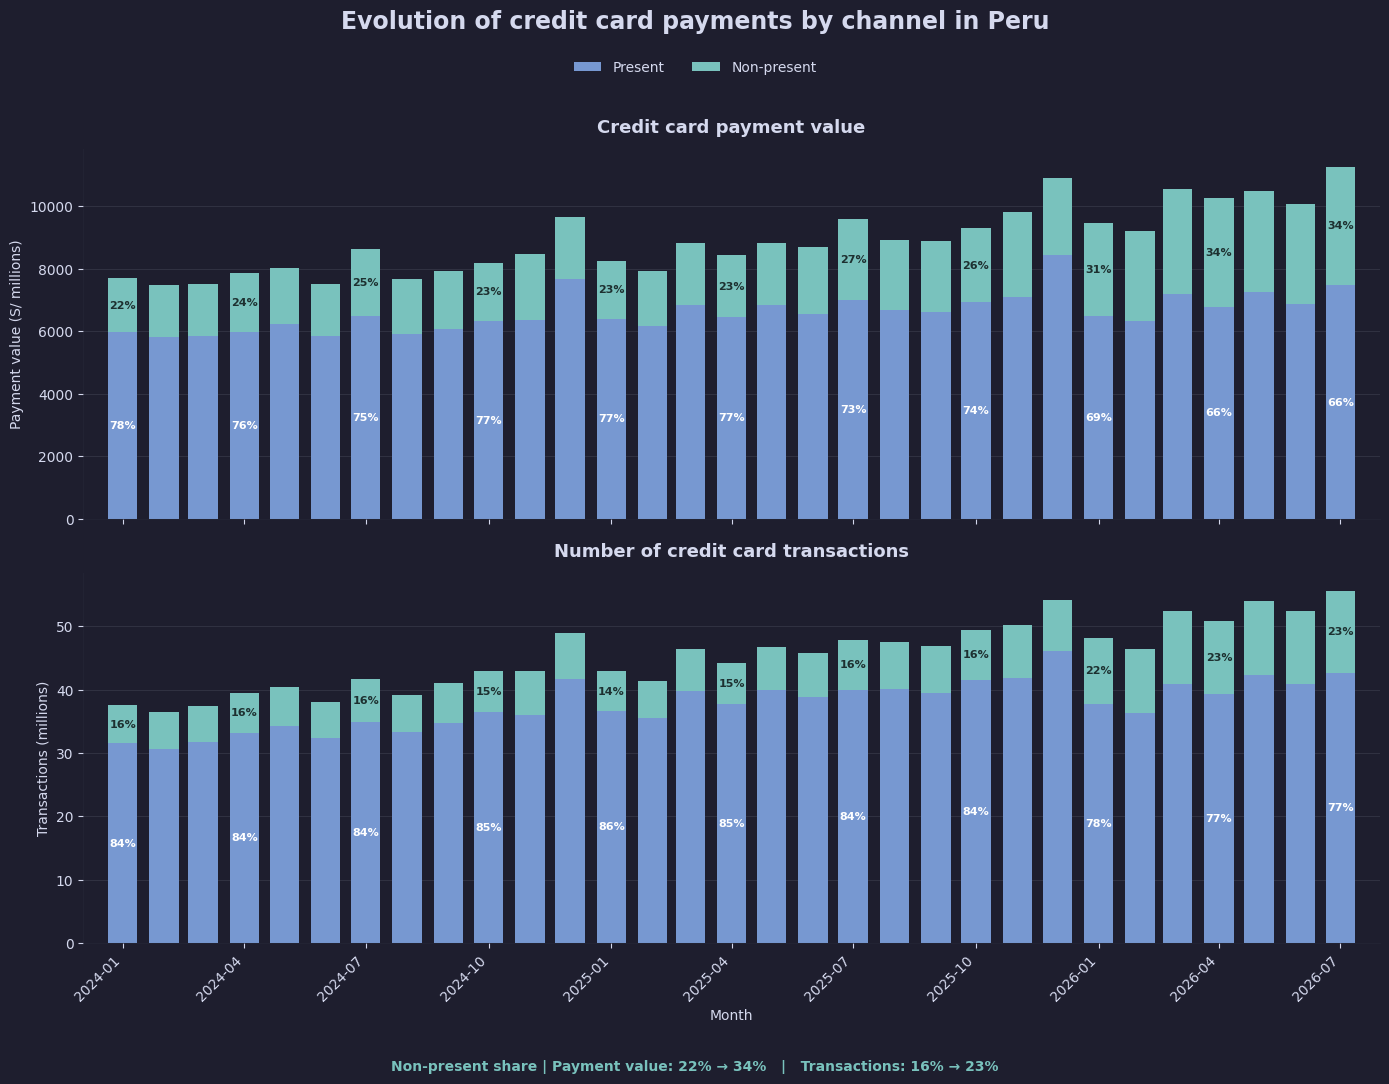

In [13]:
plot_card_channel_mix(
    card_payment_data,
    card_type="credito",
    card_label="Credit",
)

# 3. Payments via QR

The BCRP has shared in its latets report on the payment system the number of transacions via QR generated by acquirers:

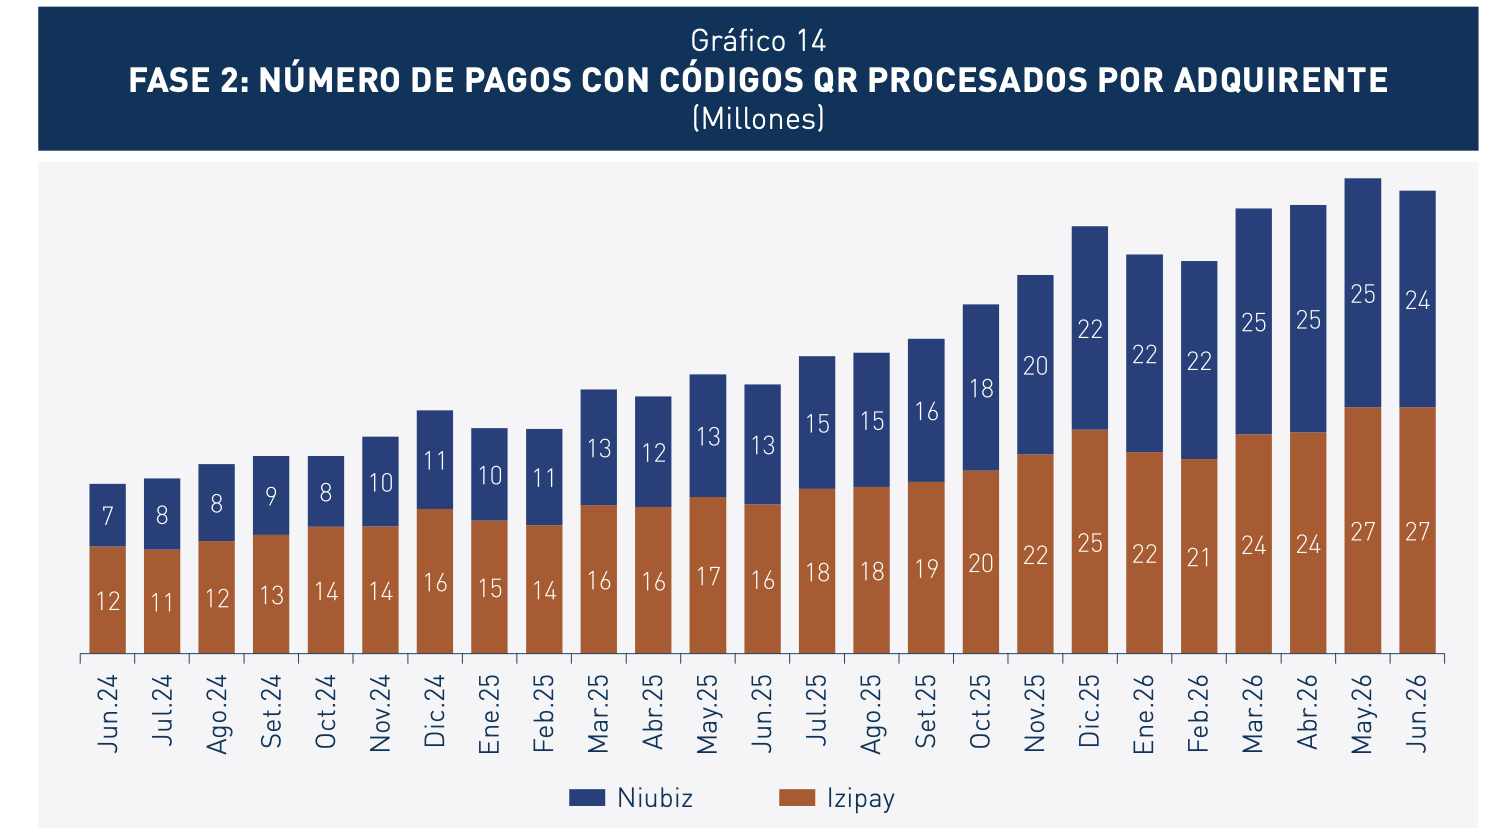

In [14]:
qr_market_data = pd.DataFrame(
    {
        "period": pd.date_range(
            start="2024-06-01",
            end="2026-06-01",
            freq="MS",
        ),
        "izipay_transactions": [
            12,
            11,
            12,
            13,
            14,
            14,
            16,
            15,
            14,
            16,
            16,
            17,
            16,
            18,
            18,
            19,
            20,
            22,
            25,
            22,
            21,
            24,
            24,
            27,
            27,
        ],
        "niubiz_transactions": [
            7,
            8,
            8,
            9,
            8,
            10,
            11,
            10,
            11,
            13,
            12,
            13,
            13,
            15,
            15,
            16,
            18,
            20,
            22,
            22,
            22,
            25,
            25,
            25,
            24,
        ],
    }
)

# Total QR transactions
qr_market_data["total_qr_transactions"] = (
    qr_market_data["izipay_transactions"] + qr_market_data["niubiz_transactions"]
)

# Market shares
qr_market_data["izipay_share"] = (
    qr_market_data["izipay_transactions"] / qr_market_data["total_qr_transactions"]
)

qr_market_data["niubiz_share"] = (
    qr_market_data["niubiz_transactions"] / qr_market_data["total_qr_transactions"]
)

# Monthly growth
qr_market_data["total_mom_growth"] = qr_market_data["total_qr_transactions"].pct_change(
    fill_method=None
)

qr_market_data["izipay_mom_growth"] = qr_market_data["izipay_transactions"].pct_change(
    fill_method=None
)

qr_market_data["niubiz_mom_growth"] = qr_market_data["niubiz_transactions"].pct_change(
    fill_method=None
)

# Year-over-year growth
qr_market_data["total_yoy_growth"] = qr_market_data["total_qr_transactions"].pct_change(
    12, fill_method=None
)

qr_market_data["izipay_yoy_growth"] = qr_market_data["izipay_transactions"].pct_change(
    12, fill_method=None
)

qr_market_data["niubiz_yoy_growth"] = qr_market_data["niubiz_transactions"].pct_change(
    12, fill_method=None
)

qr_market_data.tail()

,period,izipay_transactions,niubiz_transactions,total_qr_transactions,izipay_share,niubiz_share,total_mom_growth,izipay_mom_growth,niubiz_mom_growth,total_yoy_growth,izipay_yoy_growth,niubiz_yoy_growth
20,2026-02-01,21,22,43,0.49,0.51,-0.02,-0.05,0.00,0.72,0.50,1.00
21,2026-03-01,24,25,49,0.49,0.51,0.14,0.14,0.14,0.69,0.50,0.92
22,2026-04-01,24,25,49,0.49,0.51,0.00,0.00,0.00,0.75,0.50,1.08
23,2026-05-01,27,25,52,0.52,0.48,0.06,0.12,0.00,0.73,0.59,0.92
24,2026-06-01,27,24,51,0.53,0.47,-0.02,0.00,-0.04,0.76,0.69,0.85


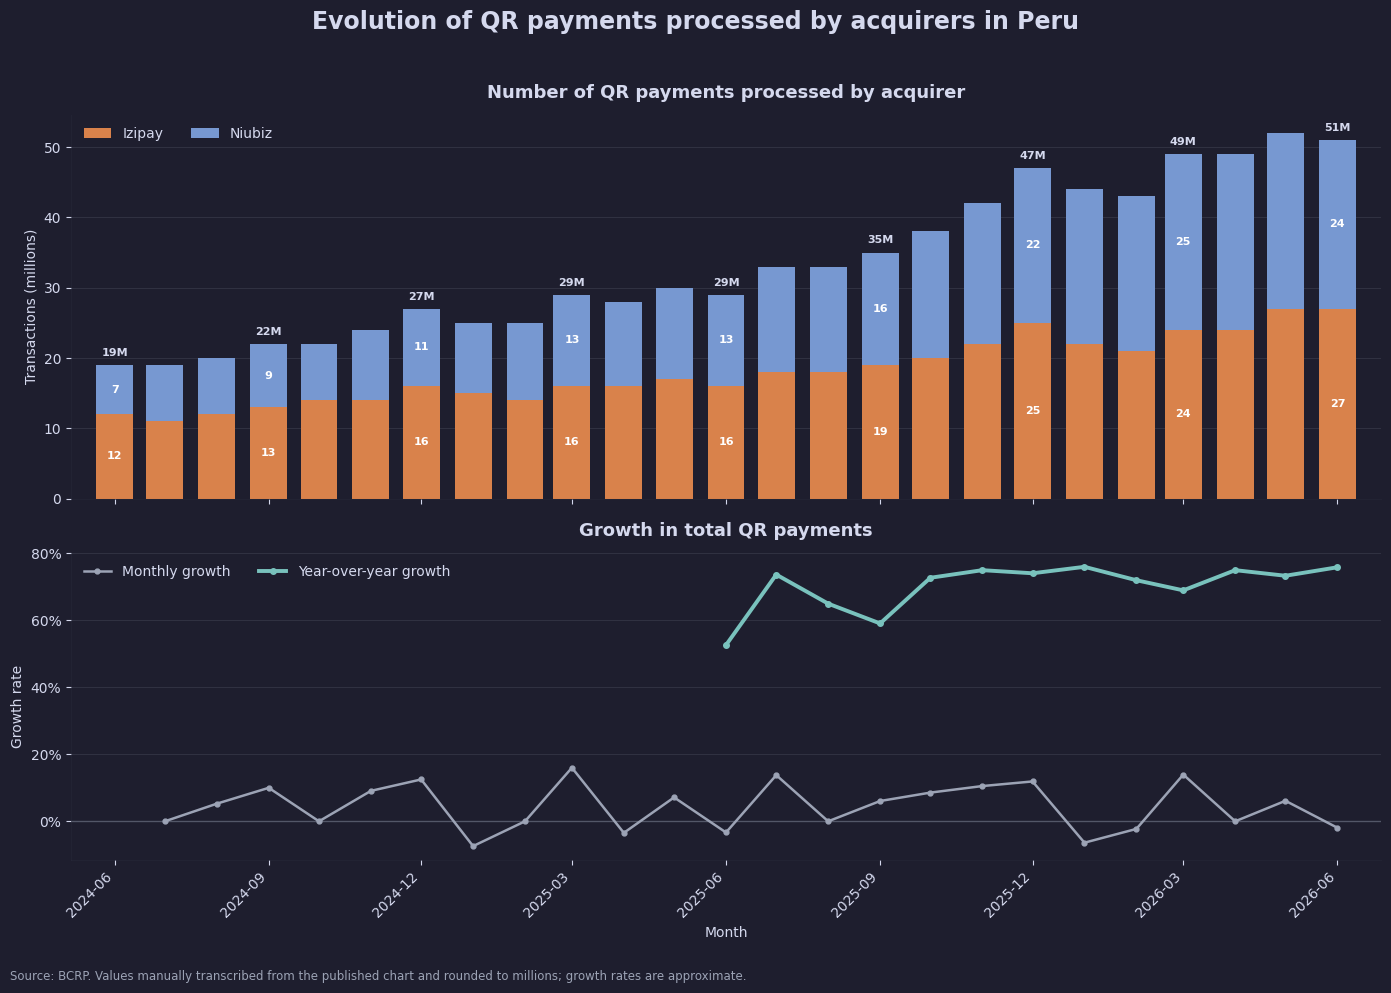

In [15]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# ------------------------------------------------------------------
# Colors
# ------------------------------------------------------------------
IZIPAY_COLOR = "#D9824B"
NIUBIZ_COLOR = "#7798D1"

MOM_COLOR = "#9CA3B5"
YOY_COLOR = "#79C2BD"

TEXT_COLOR = "#D5D9EE"
GRID_COLOR = "#5C6172"

fig, axes = plt.subplots(
    2,
    1,
    figsize=(14, 10),
    sharex=True,
    gridspec_kw={"height_ratios": [1.25, 1]},
)

fig.suptitle(
    "Evolution of QR payments processed by acquirers in Peru",
    fontsize=17,
    fontweight="bold",
    color=TEXT_COLOR,
    y=0.98,
)

bar_width = 22

# ==================================================================
# Plot 1: Number of QR payments
# ==================================================================
ax = axes[0]

ax.bar(
    qr_market_data["period"],
    qr_market_data["izipay_transactions"],
    width=bar_width,
    color=IZIPAY_COLOR,
    label="Izipay",
)

ax.bar(
    qr_market_data["period"],
    qr_market_data["niubiz_transactions"],
    width=bar_width,
    bottom=qr_market_data["izipay_transactions"],
    color=NIUBIZ_COLOR,
    label="Niubiz",
)

ax.set_title(
    "Number of QR payments processed by acquirer",
    fontsize=13,
    fontweight="bold",
    color=TEXT_COLOR,
    pad=12,
)

ax.set_ylabel(
    "Transactions (millions)",
    color=TEXT_COLOR,
)

# Labels every three months plus latest observation
label_positions = sorted(
    set(range(0, len(qr_market_data), 3)) | {len(qr_market_data) - 1}
)

for i in label_positions:
    row = qr_market_data.iloc[i]

    ax.text(
        row["period"],
        row["izipay_transactions"] / 2,
        f"{row['izipay_transactions']:.0f}",
        ha="center",
        va="center",
        fontsize=8,
        fontweight="bold",
        color="#FFFFFF",
    )

    ax.text(
        row["period"],
        (row["izipay_transactions"] + row["niubiz_transactions"] / 2),
        f"{row['niubiz_transactions']:.0f}",
        ha="center",
        va="center",
        fontsize=8,
        fontweight="bold",
        color="#FFFFFF",
    )

    ax.text(
        row["period"],
        row["total_qr_transactions"] + 1,
        f"{row['total_qr_transactions']:.0f}M",
        ha="center",
        va="bottom",
        fontsize=8,
        fontweight="bold",
        color=TEXT_COLOR,
    )

ax.legend(
    frameon=False,
    loc="upper left",
    ncol=2,
    labelcolor=TEXT_COLOR,
)

# ==================================================================
# Plot 2: Growth rates
# ==================================================================
ax = axes[1]

ax.axhline(
    0,
    color=GRID_COLOR,
    linewidth=1,
    alpha=0.8,
)

ax.plot(
    qr_market_data["period"],
    qr_market_data["total_mom_growth"],
    color=MOM_COLOR,
    linewidth=1.8,
    marker="o",
    markersize=3.5,
    label="Monthly growth",
)

ax.plot(
    qr_market_data["period"],
    qr_market_data["total_yoy_growth"],
    color=YOY_COLOR,
    linewidth=2.8,
    marker="o",
    markersize=4,
    label="Year-over-year growth",
)

ax.set_title(
    "Growth in total QR payments",
    fontsize=13,
    fontweight="bold",
    color=TEXT_COLOR,
    pad=12,
)

ax.set_ylabel(
    "Growth rate",
    color=TEXT_COLOR,
)

ax.set_xlabel(
    "Month",
    color=TEXT_COLOR,
)

ax.yaxis.set_major_formatter(mtick.PercentFormatter(1))

ax.legend(
    frameon=False,
    loc="upper left",
    ncol=2,
    labelcolor=TEXT_COLOR,
)

# ==================================================================
# Formatting
# ==================================================================
for ax in axes:
    ax.tick_params(
        axis="both",
        colors=TEXT_COLOR,
    )

    ax.grid(
        axis="y",
        color=GRID_COLOR,
        linewidth=0.7,
        alpha=0.30,
    )

    ax.grid(axis="x", visible=False)
    ax.set_axisbelow(True)
    ax.margins(x=0.02)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_alpha(0.25)
    ax.spines["bottom"].set_alpha(0.25)

axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=3))

axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

plt.setp(
    axes[1].get_xticklabels(),
    rotation=45,
    ha="right",
)

fig.text(
    0.01,
    0.01,
    "Source: BCRP. Values manually transcribed from the published chart "
    "and rounded to millions; growth rates are approximate.",
    fontsize=8.5,
    color="#9CA3B5",
    ha="left",
)

plt.tight_layout(rect=(0, 0.035, 1, 0.96))
plt.show()

In [16]:
recent_qr_growth = qr_market_data.loc[
    qr_market_data["period"] >= "2026-01-01", "total_yoy_growth"
].mean()

print(f"Average YoY growth in 2026: {recent_qr_growth:.1%}")

Average YoY growth in 2026: 73.5%
